# Amazon Beauty RQ-VAE pipeline

End-to-end run on the Amazon Product Reviews (Beauty) dataset:
1. Build embeddings (sentence-t5-base, 768d)
2. Train the RQ-VAE
3. Generate Semantic IDs

All artifacts land under `outputs/amazon_beauty_*` because `name: amazon_beauty` in the config drives the paths.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import os
import sys
from pathlib import Path

# Absolute path of your local rq-vae/ checkout. Hardcoded because some
# Jupyter setups run with cwd=/tmp, so detecting via Path.cwd() doesn't work.
ROOT = Path("/content/drive/MyDrive/tiger/rq-vae")
assert (ROOT / "src" / "amazon_beauty_dataloader.py").exists(), f"bad ROOT: {ROOT}"

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CONFIG = str(ROOT / "configs" / "amazon_beauty_config.yaml")

## 1. Build embeddings

In [3]:
from src.amazon_beauty_dataloader import prepare
from src.config import load_config

cfg = load_config(CONFIG)

# Encoding all ~259k items with sentence-t5-xxl takes hours, so reuse the
# cached artifacts if a previous run already wrote them to Drive (they live
# under outputs/ relative to ROOT, which is on Drive). Flip FORCE_REENCODE
# to rebuild from scratch.
FORCE_REENCODE = True
artifacts = [cfg["data"]["embeddings_path"], cfg["data"]["stats_path"], cfg["data"]["items_csv"]]
if not FORCE_REENCODE and all(Path(p).exists() for p in artifacts):
    print("[data] reusing cached embeddings already on Drive:")
    for p in artifacts:
        print(f"  {p}")
else:
    prepare(cfg, download=True)

[data] already downloaded at data/amazon/meta_Beauty.json.gz
[data] loaded 259204 beauty items
[data] filtered to 5-core items: 12101/259204 kept (12101 sequence items, 0 have no metadata)
[data] loading embedding model: sentence-transformers/sentence-t5-xxl


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/3.15M [00:00<?, ?B/s]

[data] encoding 12101 item texts


Batches:   0%|          | 0/379 [00:00<?, ?it/s]

[data] wrote outputs_xxl/amazon_beauty_embeddings.npy  shape=(12101, 768) dtype=float32
[data] wrote outputs_xxl/amazon_beauty_stats.npz
[data] wrote outputs_xxl/amazon_beauty_items.csv


## 2. Train the RQ-VAE

In [4]:
from src.train import train

# Reinit dead codes every 1000 steps instead of the config default (250).
# ~253 steps/epoch here, so this fires roughly once every 4 epochs.
# cfg["train"]["reinit_every"] = 1000
cfg["train"]["lr"] = 0.1          # was 0.4 — encoder was outrunning the EMA codebook

history = train(cfg)

[train] device=cuda
[train] loaded embeddings (12101, 768)
[train] model L=3  K=256  D=32
[train] k-means init done on full corpus (12101 latents)
[train] epoch   1/20000  loss=332969.3268  recon=332110.2534  rq=859.0367
[train] epoch   2/20000  loss=459.1485  recon=417.6655  rq=41.4830
[train] epoch   3/20000  loss=8.0899  recon=1.8761  rq=6.2138
[train] epoch   4/20000  loss=4.4901  recon=1.0383  rq=3.4517
[train] epoch   5/20000  loss=3.5607  recon=0.9870  rq=2.5737
[train] epoch   6/20000  loss=3.0880  recon=0.9826  rq=2.1054
[train] epoch   7/20000  loss=2.7713  recon=0.9640  rq=1.8073
[train] epoch   8/20000  loss=2.5568  recon=0.9585  rq=1.5983
[train] epoch   9/20000  loss=2.3978  recon=0.9552  rq=1.4426
[train] epoch  10/20000  loss=2.2771  recon=0.9579  rq=1.3192
[train] epoch  11/20000  loss=2.1724  recon=0.9517  rq=1.2206
[train] epoch  12/20000  loss=2.0880  recon=0.9505  rq=1.1375
[train] epoch  13/20000  loss=2.0191  recon=0.9520  rq=1.0671
[train] epoch  14/20000  loss=

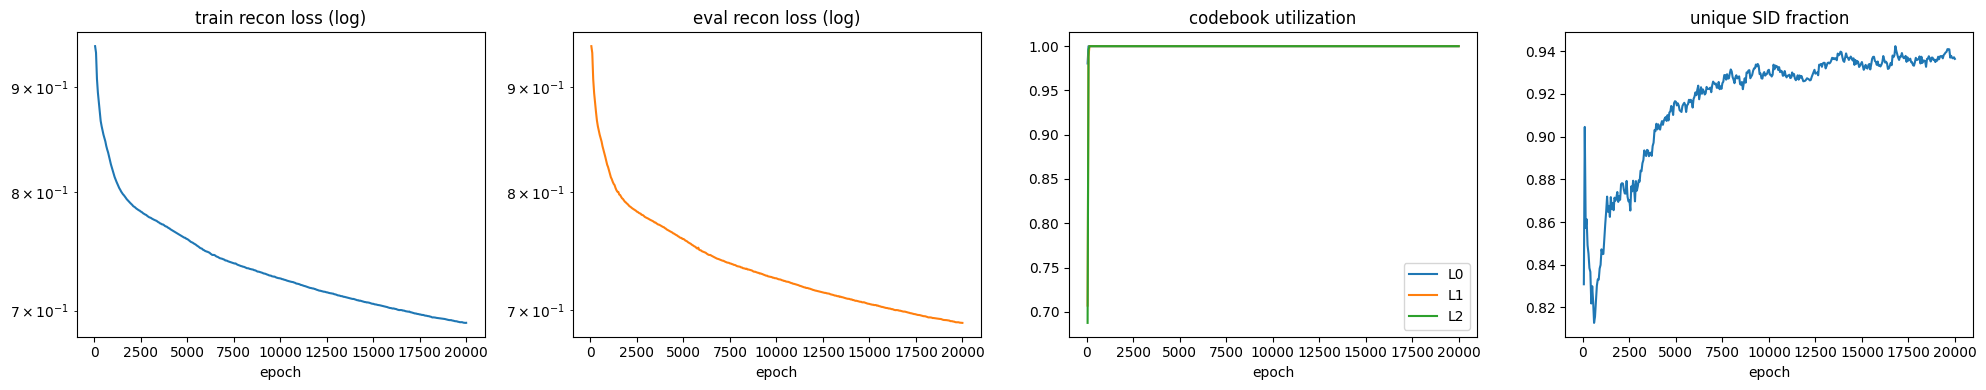

In [5]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
# train and eval recon span many orders of magnitude (train starts ~1e16),
# so use a log y-axis on each so the later, smaller values stay readable
axes[0].plot(epochs, [h["train_recon"] for h in history], color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_title("train recon loss (log)"); axes[0].set_xlabel("epoch")
axes[1].plot(epochs, [h["recon_loss"] for h in history], color="tab:orange")
axes[1].set_yscale("log")
axes[1].set_title("eval recon loss (log)"); axes[1].set_xlabel("epoch")
for l in range(len(history[0]["utilization"])):
    axes[2].plot(epochs, [h["utilization"][l] for h in history], label=f"L{l}")
axes[2].set_title("codebook utilization"); axes[2].set_xlabel("epoch"); axes[2].legend()
axes[3].plot(epochs, [h["sid_unique_fraction"] for h in history])
axes[3].set_title("unique SID fraction"); axes[3].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 3. Generate Semantic IDs

In [6]:
from src.generate_sids import generate

ckpt = Path(cfg["output"]["checkpoints_dir"]) / "best.pt"
generate(cfg, str(ckpt))

[gen] device=cuda
[gen] loaded outputs_xxl/amazon_beauty_checkpoints/best.pt  L=3 K=256
[gen] utilization per level: ['1.000', '1.000', '1.000']
[gen] perplexity per level:  ['233.89', '201.63', '201.43']
[gen] sid unique fraction:   0.9365  collisions=769
[gen] wrote outputs_xxl/amazon_beauty_sids.csv  (12101 rows)

[sample] 10 items and their SIDs:
    168-95-207  {'item_id': '7806397051', 'title': 'WAWO 15 Color Professionl Makeup Eyeshadow Camouflage Facial Concealer Neutral Palette', 'brand': 'COKA', 'categories': 'Beauty, Makeup, Face, Concealers & Neutralizers', 'price': 5.04, 'description': 'An extensive range of 15 multiple vibrant long wear concealer colour with different skin tones to create more than 10,000 amazing looks. Using the most commonly applied shades, ensures the best skin colour match and guarantees a traceless and natural finish. Enabling layering and mixing, provides total camouflage for almost any skin problem including blemishes, scars, birthmarks and black c

In [7]:
import json
import pandas as pd

sids = pd.read_csv(cfg["output"]["sids_csv"])
print(f"{len(sids)} items")
display(sids.head(10))

with open(cfg["output"]["metrics_json"]) as f:
    print(json.dumps(json.load(f), indent=2))

12101 items


,item_id,title,brand,categories,price,description,sid
0,7806397051,WAWO 15 Color Professionl Makeup Eyeshadow Cam...,COKA,"Beauty, Makeup, Face, Concealers & Neutralizers",5.04,An extensive range of 15 multiple vibrant long...,168-95-207
1,9759091062,Xtreme Brite Brightening Gel 1oz.,Xtreme Brite,"Beauty, Hair Care, Styling Products, Creams, G...",19.99,Xtreme Brite Brightening gel is a highly conc...,63-81-161
2,9788072216,Prada Candy By Prada Eau De Parfum Spray 1.7 O...,Prada,"Beauty, Fragrance, Women's, Eau de Parfum",65.86,Prada Candy By Prada Eau De Parfum Spray 1.7 O...,209-39-200
3,9790790961,Versace Bright Crystal Eau de Toilette Spray f...,Versace,"Beauty, Fragrance, Women's, Eau de Toilette",52.33,Versace Bright Crystal Perfume for Women 3 oz ...,99-110-71
4,9790794231,Stella McCartney Stella,NaN,"Beauty, Fragrance, Women's, Eau de Parfum",NaN,STELLA For Women By STELLA MCCARTNEY 1.7 oz ED...,247-110-71
5,B00004TMFE,Avalon Biotin B-Complex Thickening Conditioner...,Avalon Organics,"Beauty, Hair Care, Conditioners",9.49,It's in our name: Avalon Organics. Our commitm...,93-80-218
6,B00004TUBL,"Better Living Classic Two Chamber Dispenser, W...",Classic,"Beauty, Bath & Body, Bathing Accessories, Bath...",25.99,Qality designed two chamber that utilizes a 'p...,121-166-201
7,B00004TUBV,Better Living The Ulti-Mate Dispenser,Better Living,"Beauty, Bath & Body, Bathing Accessories, Bath...",39.95,"The Ulti-Mate Dispenser III, provides a perfec...",14-234-91
8,B00004U9V2,Crabtree &amp; Evelyn - Gardener's Ultra-Moist...,NaN,"Beauty, Skin Care, Hands & Nails, Hand Creams ...",NaN,After a long day of handling thorny situations...,108-191-58
9,B00004U9UY,Crabtree &amp; Evelyn 2792 Gardeners Hand Ther...,Crabtree &amp; Evelyn,"Beauty, Skin Care, Hands & Nails, Hand Creams ...",18.19,You've watched your favorite gardeners spend h...,133-227-124


{
  "recon_loss": 0.6901493278054913,
  "utilization": [
    1.0,
    1.0,
    1.0
  ],
  "perplexity": [
    233.89407348632812,
    201.6331329345703,
    201.42739868164062
  ],
  "sid_unique_fraction": 0.9364515329311627,
  "sid_collisions": 769,
  "final_utilization": [
    1.0,
    1.0,
    1.0
  ],
  "final_perplexity": [
    233.89407348632812,
    201.6331329345703,
    201.42739868164062
  ],
  "final_sid_unique_fraction": 0.9364515329311627,
  "final_sid_collisions": 769
}
